<div style="
    width: 100%;
    background-color: #5FA7A0;
    padding: 26px 0;
    margin-bottom: 32px;
">
  <div style="max-width: 1200px; margin: auto; text-align: center;">
    <img src="schematic.png"
         style="width: 30%; max-width: 1100px;">
  </div>
</div>

# Neural-Network–Based Continuum Background Inpainting for COSI

## Overview

This notebook provides a practical introduction to neural-network–based background inpainting for COSI data using the `ContinuumEstimationNN` class in cosipy. The purpose of this tutorial is to demonstrate how graph-based machine learning methods can be used to estimate the continuum background. This approach reconstructs (inpaints) the background for regions of the Compton data space (CDS) occupied by a source of interest (currently only tested for point sources). This is accomplished by learning spatial correlations on the sky. The resulting background estimate can be used directly in COSI analysis.


## What This Method Does

At a high level, the inpainting procedure consists of the following steps:

1. Project COSI data into the 3D Compton data space (CDS) spanned by measured energy (Em), Compton scatter angle (Phi), and sky coordinates (PsiChi)

2. Mask region in the CDS dominated by a point source using the point source response 

3. Train a graph-based neural network on the unmasked sky pixels

4. Predict the background in the masked region and merge the result with the observed data

The sky is discretized using HEALPix, which naturally defines a graph where each pixel is connected to its neighbors. This allows the neural network to propagate information across the sphere while respecting the underlying sky geometry.

## Training Modes

The inpainting algorithm supports three complementary training modes:

- **Self-supervised** (default)  
  No background model is required. The network learns by randomly masking a fraction of the sky and training itself to reconstruct those pixels.

- **Supervised**  
  A background model is provided and treated as ground truth in the masked regions.

- **Hybrid**  
  A weighted combination of supervised and self-supervised training. This mode leverages an existing background model while remaining robust to modeling uncertainties.

The training mode is selected with a single keyword argument, making it easy to experiment with different strategies.

## Neural Network Architecture

Two graph-based neural network architectures are available:

- **GCN (Graph Convolutional Network)**  
  A lightweight, four-layer architecture optimized for stability and speed.

- **Graph U-Net**  
  A deeper architecture that captures larger-scale structure through pooling and unpooling operations.

Both models operate directly on HEALPix graphs and are implemented using PyTorch Geometric. GPU acceleration is used automatically when available, but the method also runs on CPUs for smaller datasets and testing.

## Outputs and Diagnostics

This workflow produces:

- An **inpainted background histogram** compatible with cosipy
- Optional **Mollweide sky maps** showing the true, masked, and inpainted data for a given bin of Em and Phi
- **Training-loss diagnostics** saved during optimization
- Quantitative **accuracy evaluation plots** when a reference background model is available

These diagnostics are designed to help assess both the quality of the final background estimate and the behavior of the neural network during training.

## Limitations of the Method

In [1]:
from cosipy.background_estimation import ContinuumEstimationNN

import logging
logging.basicConfig(level=logging.INFO)

%matplotlib inline

12:36:52 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=487688;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=42752;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#45\45]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=575594;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=39480;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#67\67]8;;\
                  will not be available.                                                                           

12:36:54 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=383751;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=711110;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#34\34]8;;\
                  available                                                                                        

12:36:55 INFO      Starting 3ML!                                                                     ]8;id=418368;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=337824;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=8426;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=358734;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=701543;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=126189;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#136\136]8;;\
                  software installed and configured?                                                               

12:37:00 WARNING   No fermitools installed                                              ]8;id=743342;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=376108;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=266943;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=805603;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=804867;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=629543;file:///project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/threeML/threeML/__init__.py#345\345]8;;\
                  performances in 3ML                                                                              


WARNING UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/libpyg.so)


WARNING UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs


WARNING UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs


WARNING UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /project/ckarwin/astro/chris/my_envs/cosipy_pr_IM/lib/python3.10/site-packages/torch_spli

The notebook requires the following files:
1) DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori
2) SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.nonsparse_nside8.area.good_chunks_unzip.earthocc.h5
3) crab_bkg_binned_data_galactic.hdf5
4) inputs_crab.yaml

They can be downloaded using the cells below.

In [ ]:
# Update to your desired path
data_path = Path("")

In [ ]:
# DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori
fetch_wasabi_file('COSI-SMEX/DC3/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori', checksum = 'e5e71e3528e39b855b0e4f74a1a2eebe')

In [ ]:
dr = data_path / "SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5"

# download response file ~596.06 MB
fetch_wasabi_file("COSI-SMEX/develop/Data/Responses/SMEXv12.Continuum.HEALPixO3_10bins_log_flat.binnedimaging.imagingresponse.h5", checksum = 'eb72400a1279325e9404110f909c7785')

In [ ]:
# crab_bkg_binned_data_galactic.hdf5
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimation/crab_bkg_binned_data_galactic.hdf5', checksum = '7450f8ecdf6bf14bffe22d0046d47d49')

In [ ]:
# inputs_crab.yaml
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/background_estimation/inputs_crab.yaml', checksum = '3b2c6ddd35d98346d9aac13ce3d59368')

Define instance of class:

In [2]:
data_path = "/project/ckarwin/astro/chris/cosi/cosipy_development/continuum_bg_estimation/ai_inpainting/Run_1/dc3_data/"
input_data = data_path + "crab_and_bg_combined_binned_data.h5"
psr_file = data_path + "crab_psr.h5"
background_model = data_path + "Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5"

In [3]:
instance = ContinuumEstimationNN()

In [4]:
instance.estimate_bg(input_data, psr_file, background_model=None,
            training_mode="self", containment=0.6, epochs=1, model_type="gcn",
            nn_model="new", nn_model_file=None, nn_model_savename="inpainting_nn_model",
            lr=1e-3, self_mask_fraction=0.1, lambda_sup=0.5, lambda_self=0.5,
            prefix="inpainted", visualize=False, em_bin=2, phi_bin=4,
            evaluate_only=False, inpainted_file=None,
            evaluate=False, show_plots=False, verbose=False)

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:No GPU detected. Using CPU.
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GCN model.


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_estimated_bg.h5
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 4.40 seconds


INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:No GPU detected. Using CPU.
INFO:cosipy.background_estimation.ContinuumEstimationNN:Using GCN model.
INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_estimated_bg.h5


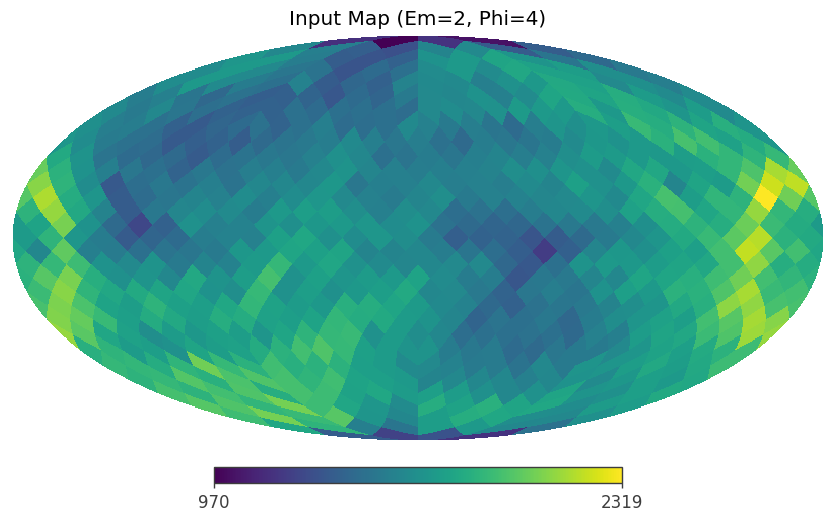

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_true_E2_Phi4.pdf


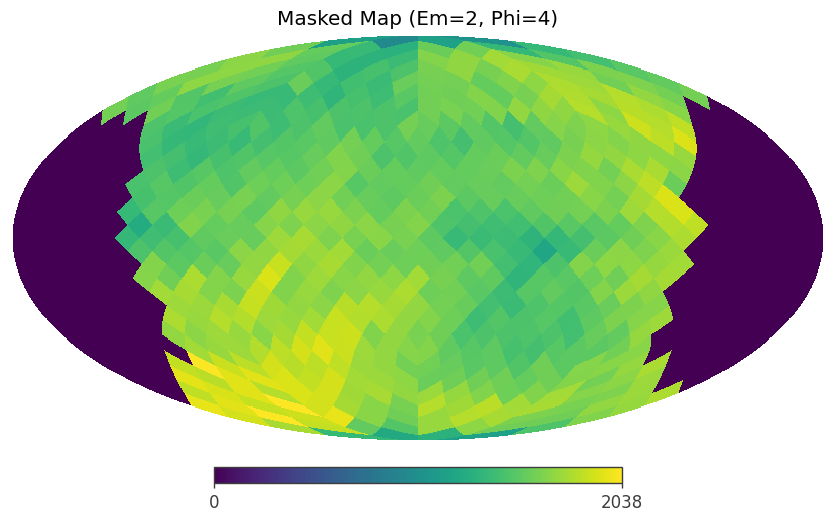

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_masked_E2_Phi4.pdf


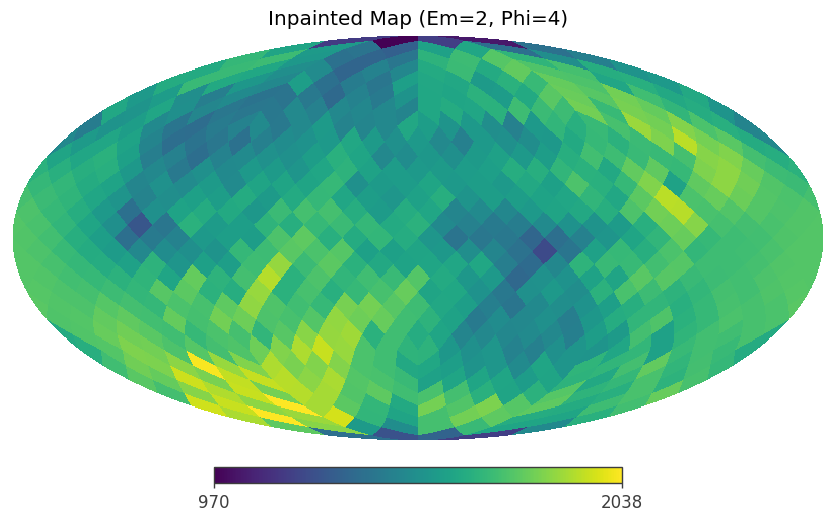

INFO:cosipy.background_estimation.ContinuumEstimationNN:Saved visualization: inpainted_inpainted_E2_Phi4.pdf


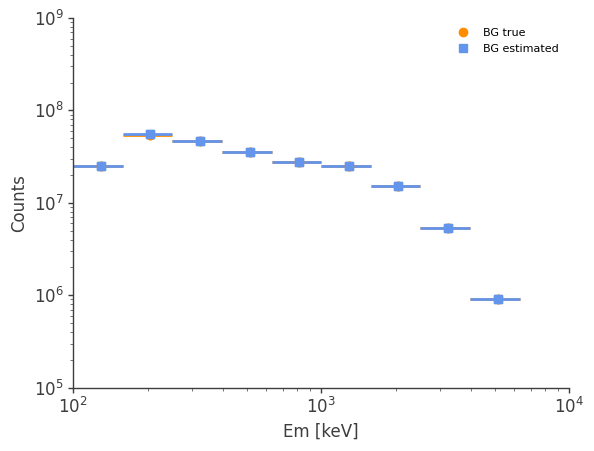

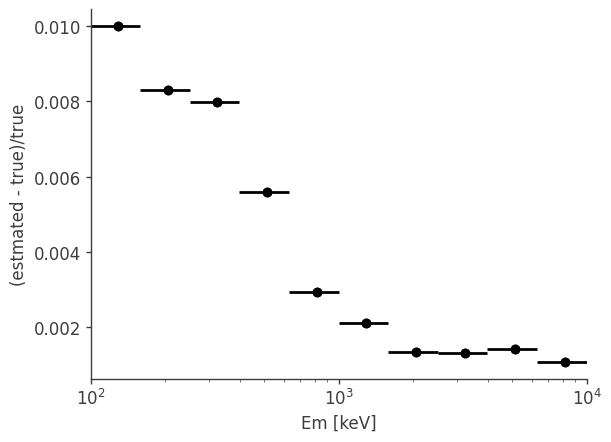

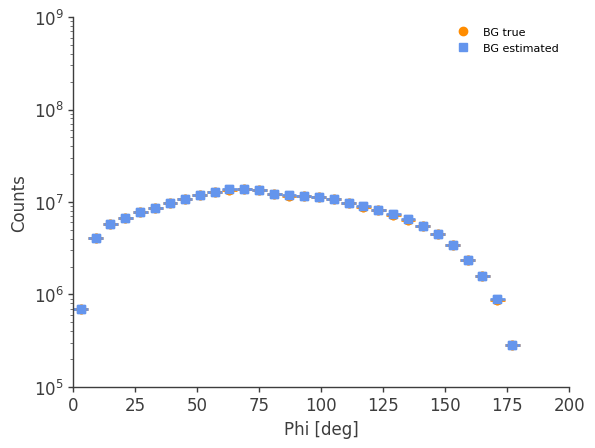

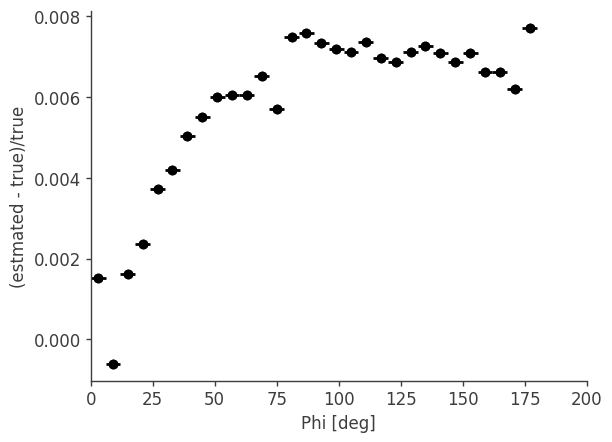

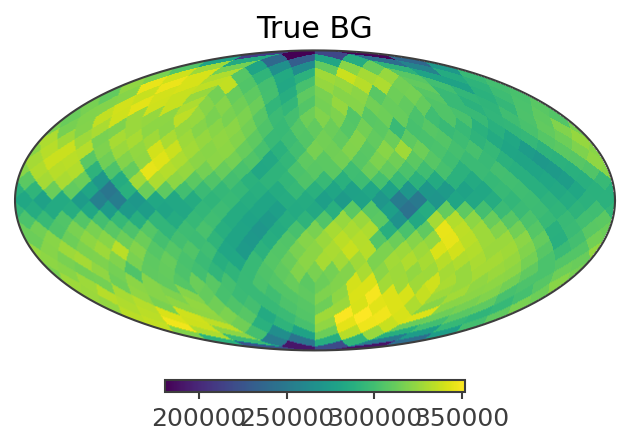

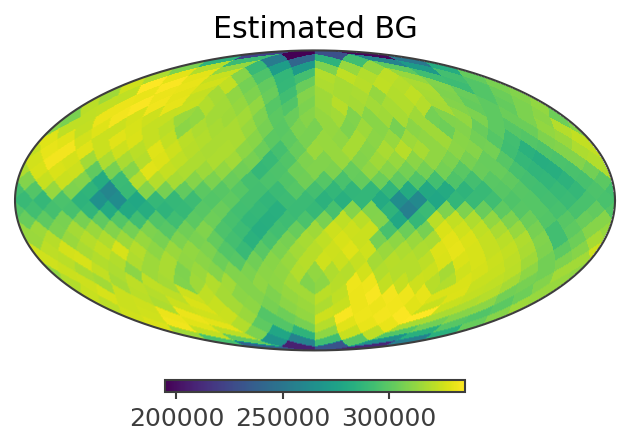


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: divide by zero encountered in divide



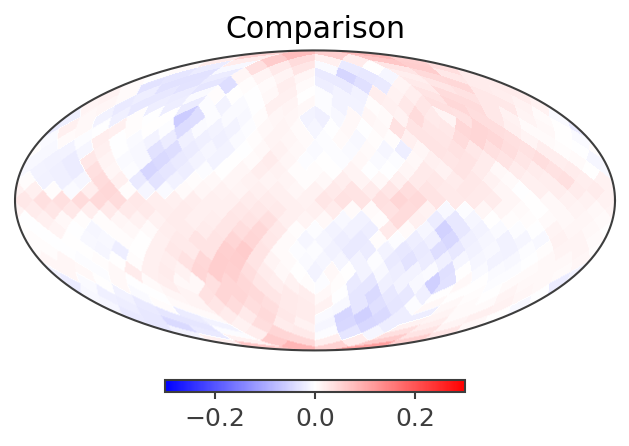

INFO:cosipy.background_estimation.ContinuumEstimationNN:Accuracy plots saved with prefix 'inpainted_...'
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 1991.96 seconds


In [10]:
instance.estimate_bg(input_data, psr_file, background_model=background_model,
        training_mode="supervised", containment=0.6, epochs=600, 
        evaluate=True, show_plots=True, visualize=True, verbose=False)

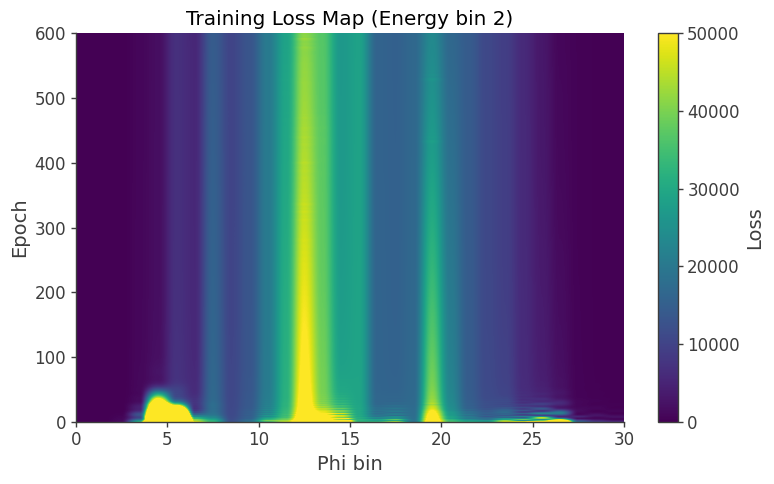

In [11]:
for E in range(2,3):
    instance.plot_training_loss("training_loss.npy",E,"training_loss")

In [5]:
instance.estimate_bg(input_data, psr_file, background_model=background_model,
        training_mode="supervised", containment=0.6, epochs=2,
        nn_model="load", nn_model_file="inpainting_nn_model.pth", nn_model_savename="inpainting_nn_model_example", verbose=False)

INFO:cosipy.background_estimation.ContinuumEstimationNN:...loading the pre-computed point source response ...
INFO:cosipy.background_estimation.ContinuumEstimationNN:--> done

WARNING RuntimeWarning: invalid value encountered in divide

INFO:cosipy.background_estimation.ContinuumEstimationNN:No GPU detected. Using CPU.
INFO:cosipy.background_estimation.ContinuumEstimationNN:loading NN model...
INFO:cosipy.background_estimation.ContinuumEstimationNN:Loaded NN model (weights only) from inpainting_nn_model.pth


Inpainting (Em, Phi):   0%|          | 0/300 [00:00<?, ?map/s]

INFO:cosipy.background_estimation.ContinuumEstimationNN:Inpainted histogram saved to inpainted_estimated_bg.h5
INFO:cosipy.background_estimation.ContinuumEstimationNN:Total time elapsed: 7.14 seconds
